In [1]:
import os
import numpy as np
import tensorflow as tf

from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import Input
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, ReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

## 1. Основні налаштування

In [2]:
num_classes = 7
img_size = (224, 224)
batch_size = 32

train_data_dir = r'train2'
validation_data_dir = r'test2'

# 7 класів (типово для FER2013)
CLASS_NAMES = ["angry", "happy", "sad", "surprise", "neutral"]

In [3]:
epochs_head = 15          # тільки новий "класифікатор"
epochs_finetune = 10     # fine-tuning бази

## 2. Генератори даних

In [4]:

train_data = image_dataset_from_directory(
    train_data_dir,
    labels='inferred',
    label_mode='int',
    class_names=CLASS_NAMES,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True
)

validation_data = image_dataset_from_directory(
    validation_data_dir,
    labels='inferred',
    label_mode='int',
    class_names=CLASS_NAMES,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

Found 20170 files belonging to 5 classes.
Found 5813 files belonging to 5 classes.


In [5]:
# Нормалізація /255
# grayscale треба перетворити на 3 канали (RGB)
def normalize_and_to_rgb(images, labels):
    images = tf.cast(images, tf.float32)

    # Якщо канал 1, зробимо RGB
    if images.shape.rank ==4 and images.shape[-1] ==1:
        images = tf.image.grayscale_to_rgb(images)

    images = images / 255.0
    return images, labels

In [6]:
AUTOTUNE = tf.data.AUTOTUNE
train_data = train_data.map(normalize_and_to_rgb, 
                            num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
validation_data = validation_data.map(normalize_and_to_rgb, 
                            num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

## 3. MobileNetV2

In [7]:
base_model = MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=(img_size[0], img_size[1], 3)
)
base_model.trainable = False

# "Голова" класифікатора: Dense -> ReLU -> Dense -> ReLU -> Softmax(7)
inputs = Input(shape=(img_size[0], img_size[1], 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)

x = Dense(256)(x)
x = ReLU()(x)

x = Dense(128)(x)
x = ReLU()(x)

outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)

In [8]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu (ReLU)                         │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_1 (ReLU)                       │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 7)                   │             903 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,619,719 (9.99 MB)

 Trainable params: 361,735 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

None


## 4. Callbacks

In [9]:
checkpoint = ModelCheckpoint(
    'Emotion_mobilenetv2_5cls.h5',
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    verbose=1
)

earlystop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    verbose=1,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    verbose=1,
    min_delta=1e-4
)

callbacks = [earlystop, checkpoint, reduce_lr]

## 5. ЕТАП 1: тренування тільки "голови"

In [10]:

steps_per_epoch = tf.data.experimental.cardinality(train_data).numpy()
validation_steps = tf.data.experimental.cardinality(validation_data).numpy()

print("\n=== Stage 1: train classifier head ===")
history_head = model.fit(
    train_data,
    steps_per_epoch=steps_per_epoch,
    epochs=epochs_head,
    validation_data=validation_data,
    validation_steps=validation_steps,
    callbacks=callbacks
)


=== Stage 1: train classifier head ===
Epoch 1/15
631/631 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - accuracy: 0.3938 - loss: 1.4410
Epoch 1: val_loss improved from inf to 1.17864, saving model to Emotion_mobilenetv2_5cls.h5


631/631 ━━━━━━━━━━━━━━━━━━━━ 407s 637ms/step - accuracy: 0.3939 - loss: 1.4408 - val_accuracy: 0.5384 - val_loss: 1.1786 - learning_rate: 1.0000e-04
Epoch 2/15
631/631 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step - accuracy: 0.5452 - loss: 1.1323
Epoch 2: val_loss improved from 1.17864 to 1.10204, saving model to Emotion_mobilenetv2_5cls.h5


631/631 ━━━━━━━━━━━━━━━━━━━━ 395s 626ms/step - accuracy: 0.5452 - loss: 1.1323 - val_accuracy: 0.5677 - val_loss: 1.1020 - learning_rate: 1.0000e-04
Epoch 3/15
631/631 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step - accuracy: 0.5876 - loss: 1.0547
Epoch 3: val_loss improved from 1.10204 to 1.07043, saving model to Emotion_mobilenetv2_5cls.h5


631/631 ━━━━━━━━━━━━━━━━━━━━ 395s 626ms/step - accuracy: 0.5876 - loss: 1.0547 - val_accuracy: 0.5797 - val_loss: 1.0704 - learning_rate: 1.0000e-04
Epoch 4/15
631/631 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step - accuracy: 0.6118 - loss: 0.9999
Epoch 4: val_loss improved from 1.07043 to 1.06654, saving model to Emotion_mobilenetv2_5cls.h5


631/631 ━━━━━━━━━━━━━━━━━━━━ 393s 623ms/step - accuracy: 0.6118 - loss: 0.9999 - val_accuracy: 0.5852 - val_loss: 1.0665 - learning_rate: 1.0000e-04
Epoch 5/15
631/631 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - accuracy: 0.6377 - loss: 0.9532
Epoch 5: val_loss improved from 1.06654 to 1.05075, saving model to Emotion_mobilenetv2_5cls.h5


631/631 ━━━━━━━━━━━━━━━━━━━━ 398s 630ms/step - accuracy: 0.6377 - loss: 0.9532 - val_accuracy: 0.5882 - val_loss: 1.0508 - learning_rate: 1.0000e-04
Epoch 6/15
631/631 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.6496 - loss: 0.9147
Epoch 6: val_loss improved from 1.05075 to 1.04860, saving model to Emotion_mobilenetv2_5cls.h5


631/631 ━━━━━━━━━━━━━━━━━━━━ 396s 627ms/step - accuracy: 0.6496 - loss: 0.9147 - val_accuracy: 0.5926 - val_loss: 1.0486 - learning_rate: 1.0000e-04
Epoch 7/15
631/631 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.6638 - loss: 0.8746
Epoch 7: val_loss improved from 1.04860 to 1.03440, saving model to Emotion_mobilenetv2_5cls.h5


631/631 ━━━━━━━━━━━━━━━━━━━━ 394s 625ms/step - accuracy: 0.6638 - loss: 0.8746 - val_accuracy: 0.5944 - val_loss: 1.0344 - learning_rate: 1.0000e-04
Epoch 8/15
631/631 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.6841 - loss: 0.8387
Epoch 8: val_loss did not improve from 1.03440
631/631 ━━━━━━━━━━━━━━━━━━━━ 396s 628ms/step - accuracy: 0.6841 - loss: 0.8387 - val_accuracy: 0.5938 - val_loss: 1.0391 - learning_rate: 1.0000e-04
Epoch 9/15
631/631 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step - accuracy: 0.7002 - loss: 0.8037
Epoch 9: val_loss did not improve from 1.03440
631/631 ━━━━━━━━━━━━━━━━━━━━ 393s 623ms/step - accuracy: 0.7002 - loss: 0.8037 - val_accuracy: 0.5990 - val_loss: 1.0379 - learning_rate: 1.0000e-04
Epoch 10/15
631/631 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step - accuracy: 0.7170 - loss: 0.7708
Epoch 10: val_loss did not improve from 1.03440

Epoch 10: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
631/631 ━━━━━━━━━━━━━━━━━━━━ 395s 625ms/step - accuracy: 0.7170 - l

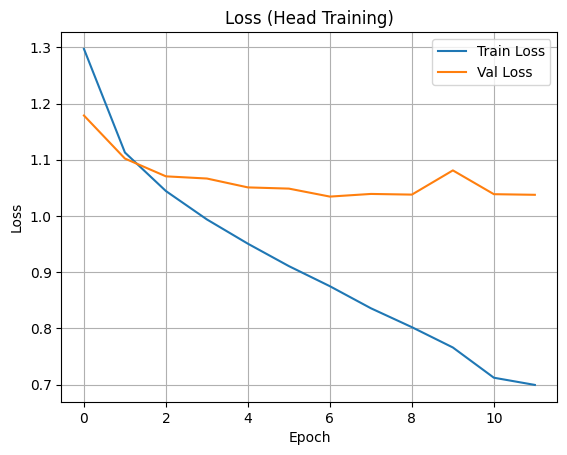

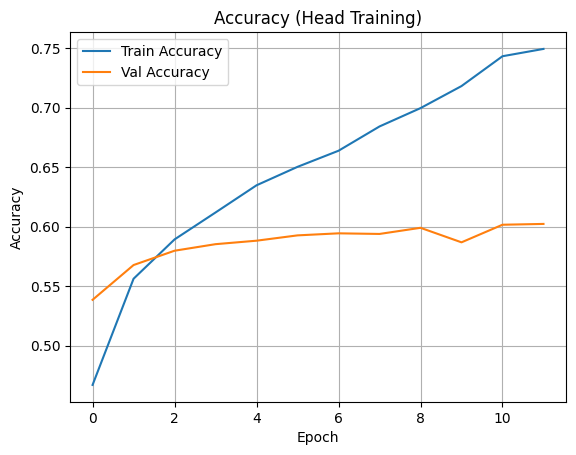

In [11]:
# Графіків після навчання "голови"
plt.figure()
plt.plot(history_head.history['loss'], label='Train Loss')
plt.plot(history_head.history['val_loss'], label='Val Loss')
plt.title('Loss (Head Training)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(history_head.history['accuracy'], label='Train Accuracy')
plt.plot(history_head.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy (Head Training)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

182/182 ━━━━━━━━━━━━━━━━━━━━ 91s 491ms/step
Validation Accuracy after Head Training: 0.5943574746258387


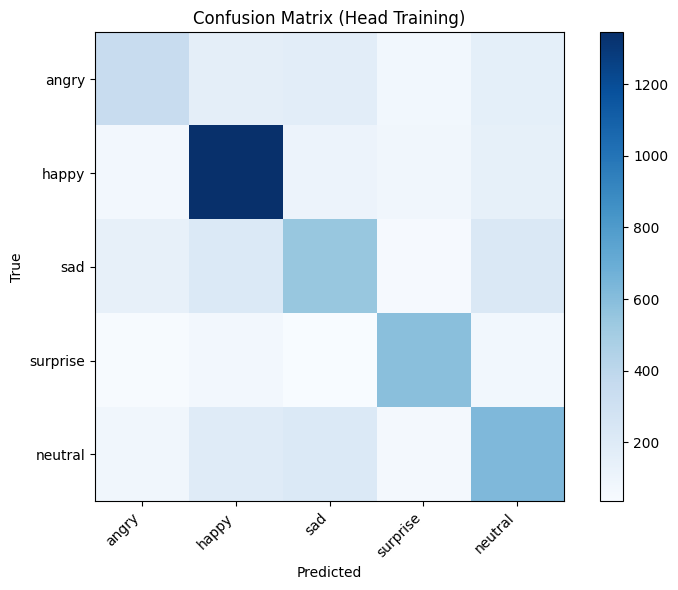

Classification Report after Head Training:
               precision    recall  f1-score   support

       angry     0.5154    0.3866    0.4418       908
       happy     0.6786    0.7717    0.7221      1743
         sad     0.5074    0.4638    0.4847      1175
    surprise     0.6941    0.7266    0.7100       812
     neutral     0.5090    0.5311    0.5198      1175

    accuracy                         0.5944      5813
   macro avg     0.5809    0.5759    0.5757      5813
weighted avg     0.5864    0.5944    0.5877      5813



In [12]:
# === Прогнози на валідаційному наборі
y_prob = model.predict(validation_data)
y_pred = np.argmax(y_prob, axis=1)

# === Отримуємо справжні мітки
y_true = np.concatenate([y for x, y in validation_data], axis=0)

# === Оцінка
val_acc = accuracy_score(y_true, y_pred)
print("Validation Accuracy after Head Training:", val_acc)

# === Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
class_names = CLASS_NAMES  # Визначено раніше

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im)
ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.title("Confusion Matrix (Head Training)")
plt.tight_layout()
plt.show()

# === Classification Report
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print("Classification Report after Head Training:\n", report)

## 6. ЕТАП 2: fine-tuning останніх шарів бази

In [13]:
# === Розморозити верхні шари базової моделі для fine-tuning ===
base_model.trainable = True

# Заморозити нижні шари (залишити тільки верхні ~40 шарів trainable)
for layer in base_model.layers[:-40]:
    layer.trainable = False

# Скомпілювати модель із меншою швидкістю навчання
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)


In [14]:
print("\n=== Stage 2: Fine-tuning base model ===")
history_ft = model.fit(
    train_data,
    epochs=10,  # або більше при потребі
    validation_data=validation_data,
    callbacks=callbacks  # той самий список: earlystop, checkpoint, reduce_lr
)


=== Stage 2: Fine-tuning base model ===
Epoch 1/10
631/631 ━━━━━━━━━━━━━━━━━━━━ 0s 696ms/step - accuracy: 0.4582 - loss: 1.3362
Epoch 1: val_loss did not improve from 1.03440
631/631 ━━━━━━━━━━━━━━━━━━━━ 535s 833ms/step - accuracy: 0.4583 - loss: 1.3360 - val_accuracy: 0.5495 - val_loss: 1.2507 - learning_rate: 1.0000e-05
Epoch 2/10
631/631 ━━━━━━━━━━━━━━━━━━━━ 0s 658ms/step - accuracy: 0.6238 - loss: 0.9715
Epoch 2: val_loss did not improve from 1.03440
631/631 ━━━━━━━━━━━━━━━━━━━━ 501s 794ms/step - accuracy: 0.6238 - loss: 0.9715 - val_accuracy: 0.5961 - val_loss: 1.0468 - learning_rate: 1.0000e-05
Epoch 3/10
631/631 ━━━━━━━━━━━━━━━━━━━━ 0s 653ms/step - accuracy: 0.6742 - loss: 0.8498
Epoch 3: val_loss improved from 1.03440 to 1.03020, saving model to Emotion_mobilenetv2_5cls.h5


631/631 ━━━━━━━━━━━━━━━━━━━━ 497s 787ms/step - accuracy: 0.6742 - loss: 0.8498 - val_accuracy: 0.6028 - val_loss: 1.0302 - learning_rate: 1.0000e-05
Epoch 4/10
631/631 ━━━━━━━━━━━━━━━━━━━━ 0s 652ms/step - accuracy: 0.7121 - loss: 0.7585
Epoch 4: val_loss improved from 1.03020 to 1.00252, saving model to Emotion_mobilenetv2_5cls.h5


631/631 ━━━━━━━━━━━━━━━━━━━━ 497s 787ms/step - accuracy: 0.7121 - loss: 0.7585 - val_accuracy: 0.6171 - val_loss: 1.0025 - learning_rate: 1.0000e-05
Epoch 5/10
631/631 ━━━━━━━━━━━━━━━━━━━━ 0s 652ms/step - accuracy: 0.7413 - loss: 0.6870
Epoch 5: val_loss did not improve from 1.00252
631/631 ━━━━━━━━━━━━━━━━━━━━ 496s 786ms/step - accuracy: 0.7413 - loss: 0.6870 - val_accuracy: 0.6200 - val_loss: 1.0067 - learning_rate: 1.0000e-05
Epoch 6/10
631/631 ━━━━━━━━━━━━━━━━━━━━ 0s 651ms/step - accuracy: 0.7702 - loss: 0.6179
Epoch 6: val_loss improved from 1.00252 to 0.98731, saving model to Emotion_mobilenetv2_5cls.h5


631/631 ━━━━━━━━━━━━━━━━━━━━ 496s 785ms/step - accuracy: 0.7702 - loss: 0.6179 - val_accuracy: 0.6300 - val_loss: 0.9873 - learning_rate: 1.0000e-05
Epoch 7/10
631/631 ━━━━━━━━━━━━━━━━━━━━ 0s 651ms/step - accuracy: 0.8031 - loss: 0.5464
Epoch 7: val_loss improved from 0.98731 to 0.97131, saving model to Emotion_mobilenetv2_5cls.h5


631/631 ━━━━━━━━━━━━━━━━━━━━ 496s 786ms/step - accuracy: 0.8031 - loss: 0.5464 - val_accuracy: 0.6473 - val_loss: 0.9713 - learning_rate: 1.0000e-05
Epoch 8/10
631/631 ━━━━━━━━━━━━━━━━━━━━ 0s 653ms/step - accuracy: 0.8288 - loss: 0.4853
Epoch 8: val_loss did not improve from 0.97131
631/631 ━━━━━━━━━━━━━━━━━━━━ 497s 788ms/step - accuracy: 0.8288 - loss: 0.4853 - val_accuracy: 0.6475 - val_loss: 0.9892 - learning_rate: 1.0000e-05
Epoch 9/10
631/631 ━━━━━━━━━━━━━━━━━━━━ 0s 654ms/step - accuracy: 0.8569 - loss: 0.4169
Epoch 9: val_loss did not improve from 0.97131
631/631 ━━━━━━━━━━━━━━━━━━━━ 497s 788ms/step - accuracy: 0.8569 - loss: 0.4169 - val_accuracy: 0.6458 - val_loss: 1.0247 - learning_rate: 1.0000e-05
Epoch 10/10
631/631 ━━━━━━━━━━━━━━━━━━━━ 0s 652ms/step - accuracy: 0.8753 - loss: 0.3697
Epoch 10: val_loss did not improve from 0.97131

Epoch 10: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
631/631 ━━━━━━━━━━━━━━━━━━━━ 496s 786ms/step - accuracy: 0.8753 - l

In [15]:
# === Об'єднання історій head + fine-tune ===
history_combined = {}
for key in history_head.history:
    history_combined[key] = history_head.history[key] + history_ft.history.get(key, [])


## 7. Learning loss / accuracy

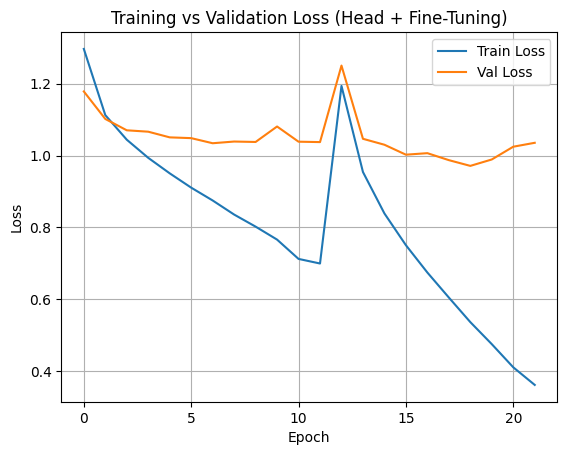

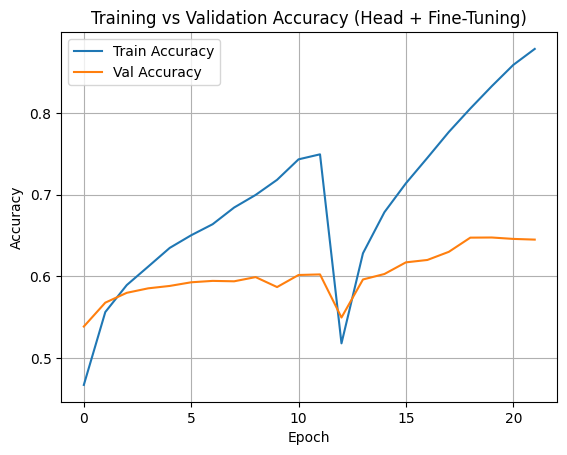

In [16]:
plt.figure()
plt.plot(history_combined['loss'], label='Train Loss')
plt.plot(history_combined['val_loss'], label='Val Loss')
plt.title('Training vs Validation Loss (Head + Fine-Tuning)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(history_combined['accuracy'], label='Train Accuracy')
plt.plot(history_combined['val_accuracy'], label='Val Accuracy')
plt.title('Training vs Validation Accuracy (Head + Fine-Tuning)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## 8. Оцінка моделі на validation set
###    (accuracy, confusion matrix)

182/182 ━━━━━━━━━━━━━━━━━━━━ 87s 471ms/step
Validation Accuracy after Fine-Tuning: 0.6473421641149149


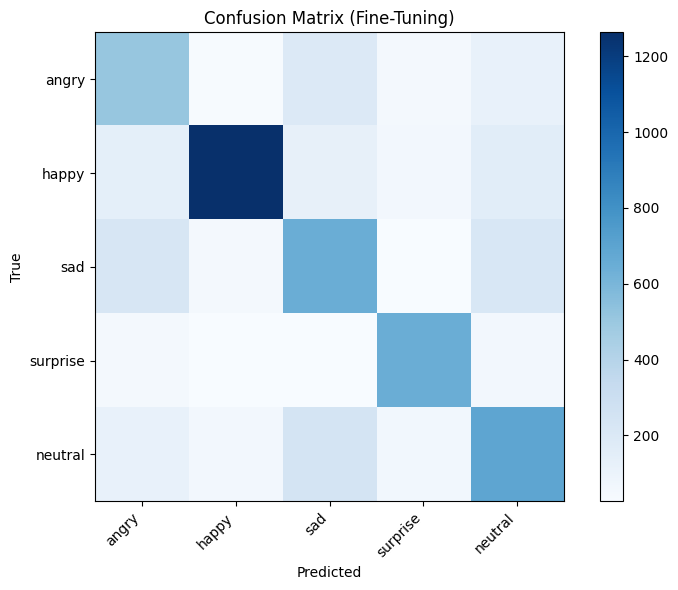

Classification Report after Fine-Tuning:
               precision    recall  f1-score   support

       angry     0.4876    0.5639    0.5230       908
       happy     0.8808    0.7246    0.7951      1743
         sad     0.5230    0.5506    0.5365      1175
    surprise     0.7680    0.7993    0.7833       812
     neutral     0.5549    0.5889    0.5714      1175

    accuracy                         0.6473      5813
   macro avg     0.6429    0.6455    0.6419      5813
weighted avg     0.6654    0.6473    0.6535      5813



In [17]:
# === Прогнозування на validation data
y_prob_ft = model.predict(validation_data)
y_pred_ft = np.argmax(y_prob_ft, axis=1)
y_true_ft = np.concatenate([y for x, y in validation_data], axis=0)

# === Оцінка якості
val_acc_ft = accuracy_score(y_true_ft, y_pred_ft)
print("Validation Accuracy after Fine-Tuning:", val_acc_ft)

# === Матриця плутанини
cm_ft = confusion_matrix(y_true_ft, y_pred_ft)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_ft, interpolation='nearest', cmap='Blues')
plt.colorbar(im)
ax.set_xticks(np.arange(len(CLASS_NAMES)))
ax.set_yticks(np.arange(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.title("Confusion Matrix (Fine-Tuning)")
plt.tight_layout()
plt.show()

# === Classification report
report_ft = classification_report(y_true_ft, y_pred_ft, target_names=CLASS_NAMES, digits=4)
print("Classification Report after Fine-Tuning:\n", report_ft)


In [18]:

# === Збереження остаточної моделі
model.save("Emotion_mobilenetv2_5cls_finetuned.h5")